In [13]:
import random
import networkx as nx
import pandas as pd
import numpy as np
from scipy.optimize import linprog
import matplotlib.pyplot as plt

In [14]:
def greedy_vertex_cover(graph):
    matching = []
    used = set()
    for start,end in graph.edges():
        if start not in used and end not in used:
            matching.append((start,end))
            used.add(start)
            used.add(end)
    vertex_cover = set()
    for start,end in matching:
        vertex_cover.add(start)
        vertex_cover.add(end)
    return matching,sorted(vertex_cover)

In [15]:
def lp_vertex_cover(graph):
    nodes = list(graph.nodes())
    index = {node:i for i,node in enumerate(nodes)}
    A = []
    for start,end in graph.edges():
        row = np.zeros(len(nodes))
        row[index[start]] = -1
        row[index[end]] = -1
        A.append(row)
    result = linprog(np.ones(len(nodes)),A_ub=A,b_ub=[-1]*len(A),bounds=[(0,1)]*len(nodes),method="highs")
    lp_values = dict(zip(nodes,result.x))
    rounded_cover = [node for node,value in lp_values.items() if value >= 0.5]
    return result.fun,rounded_cover

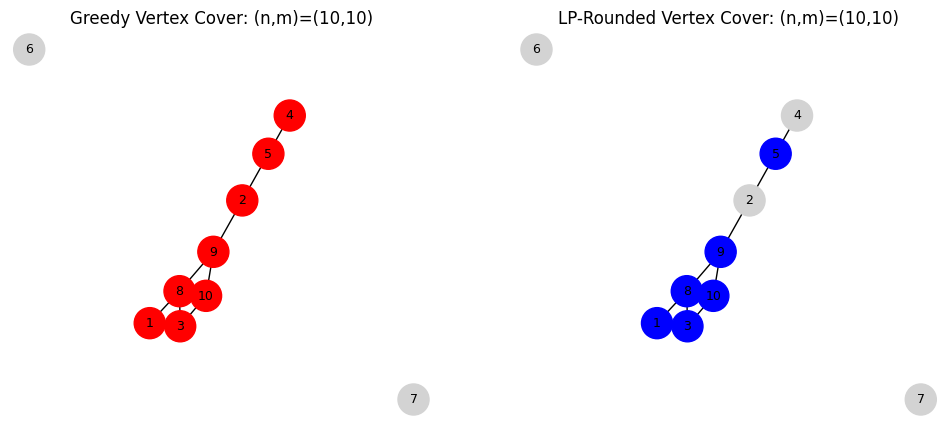

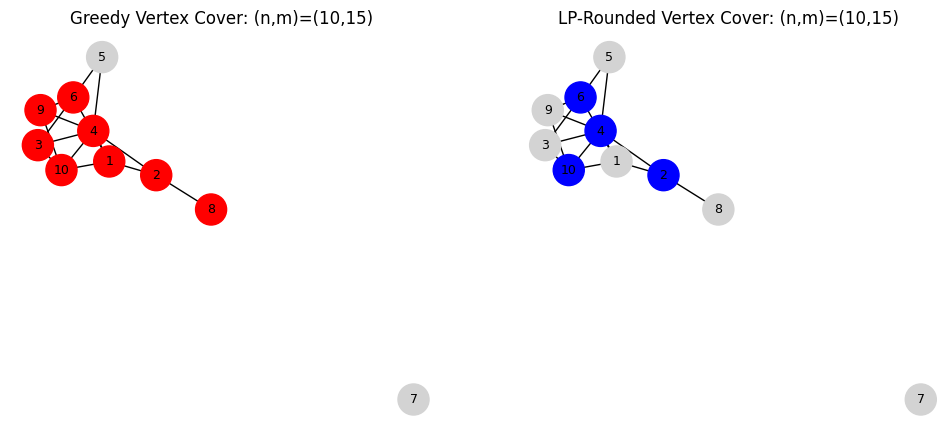

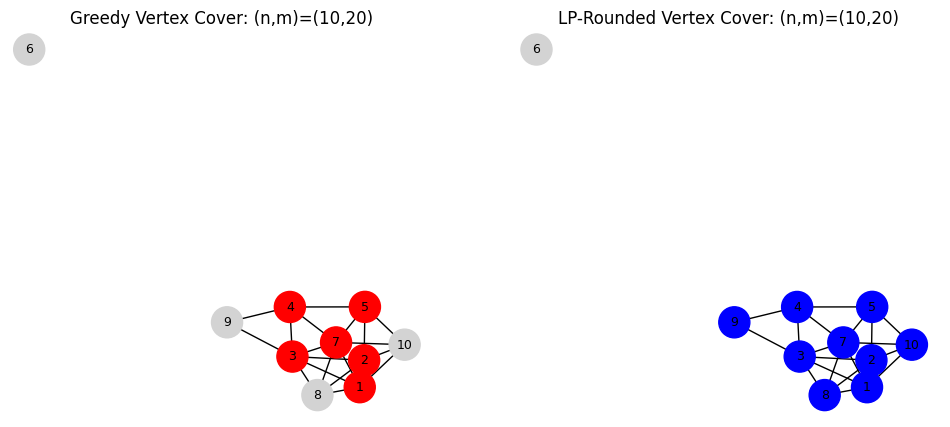

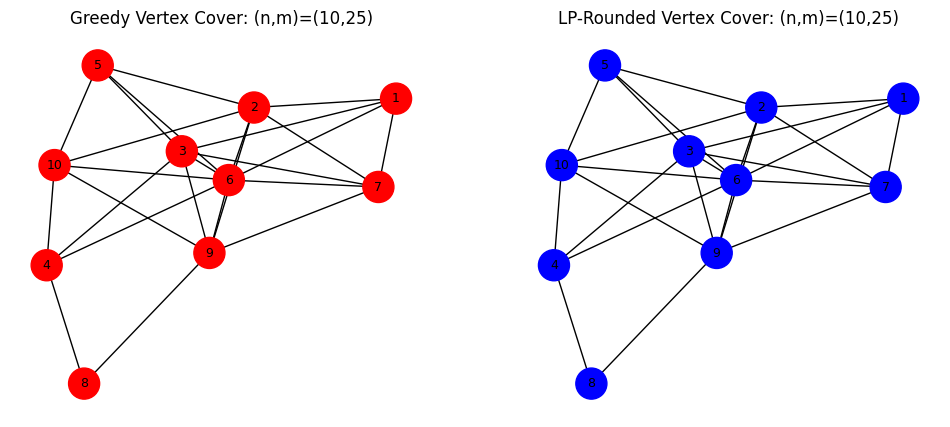

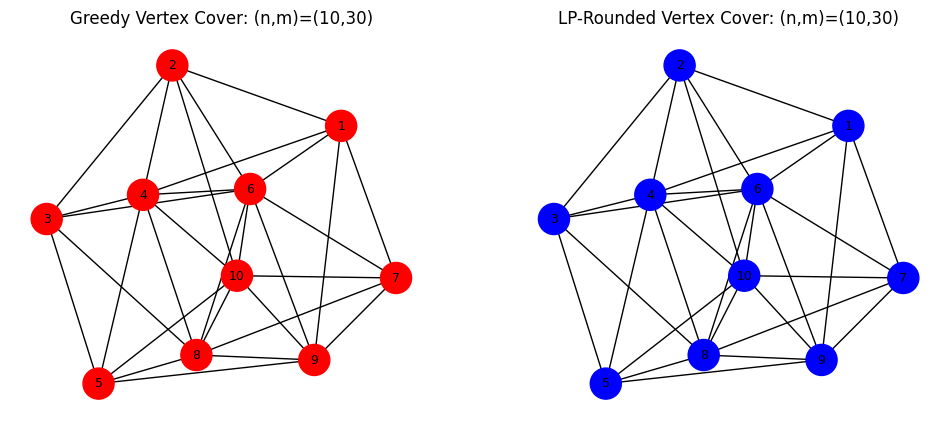

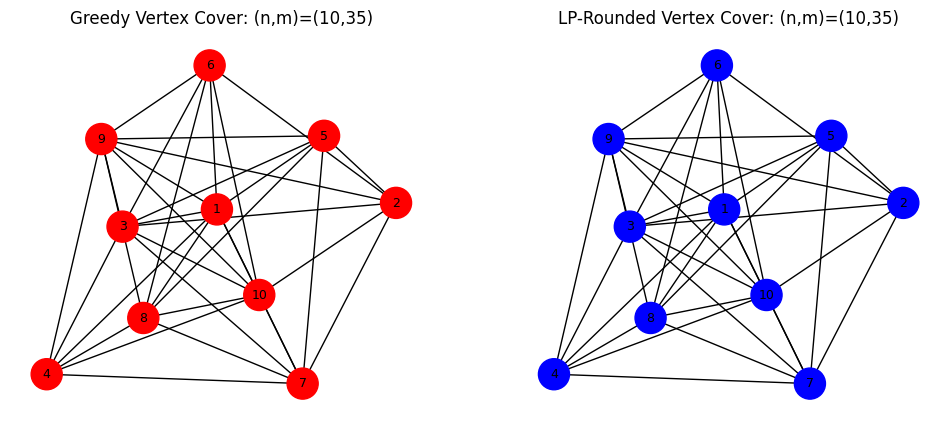

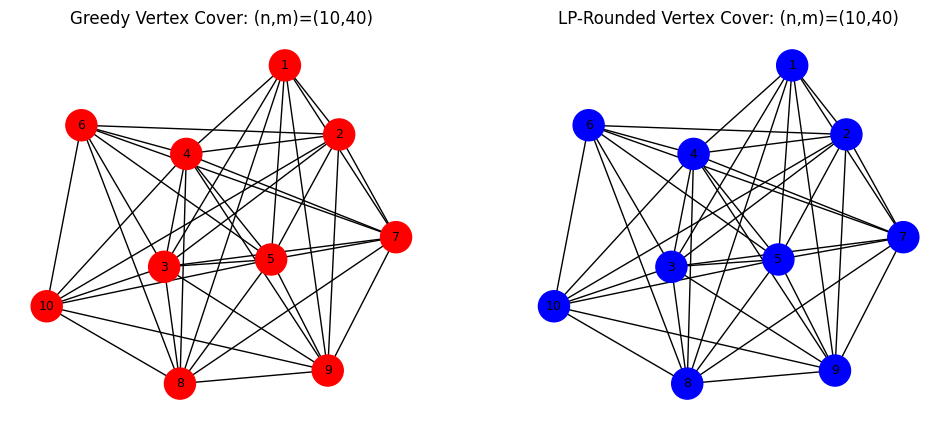

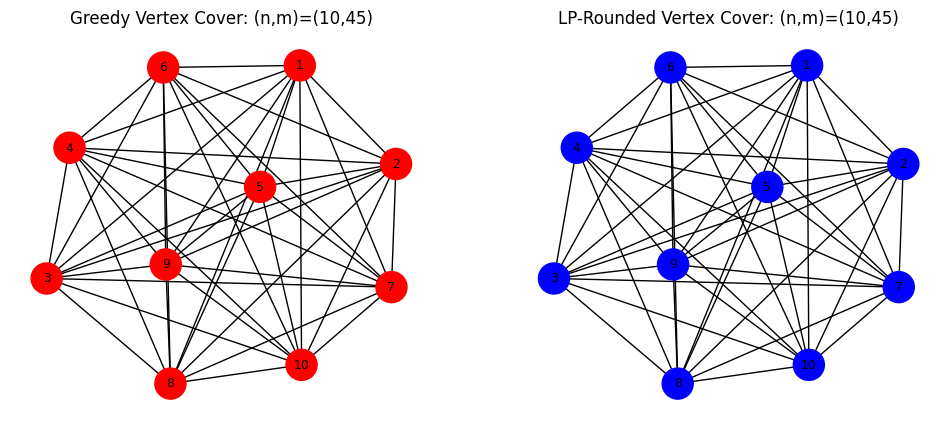

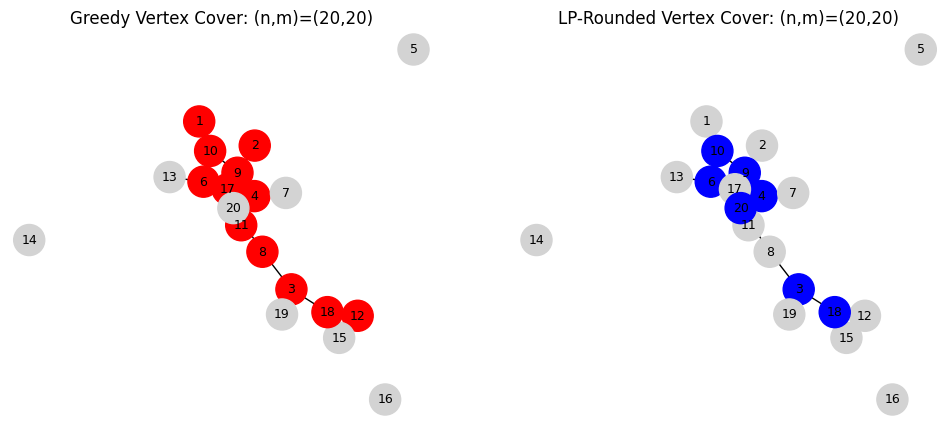

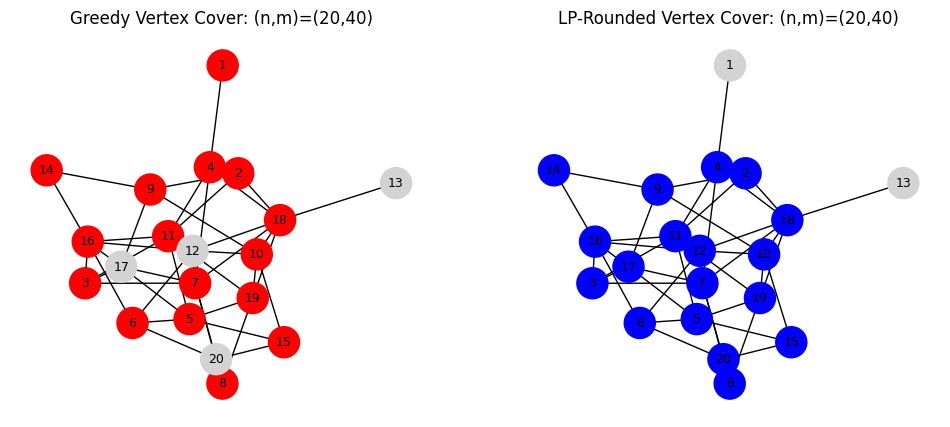

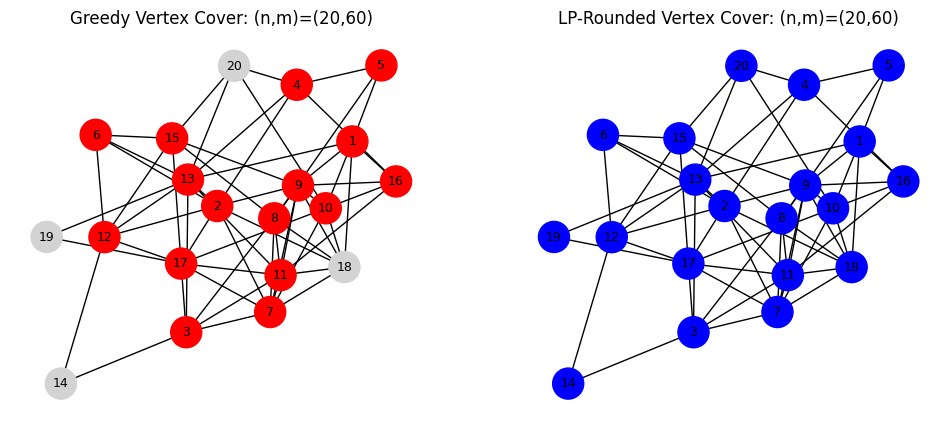

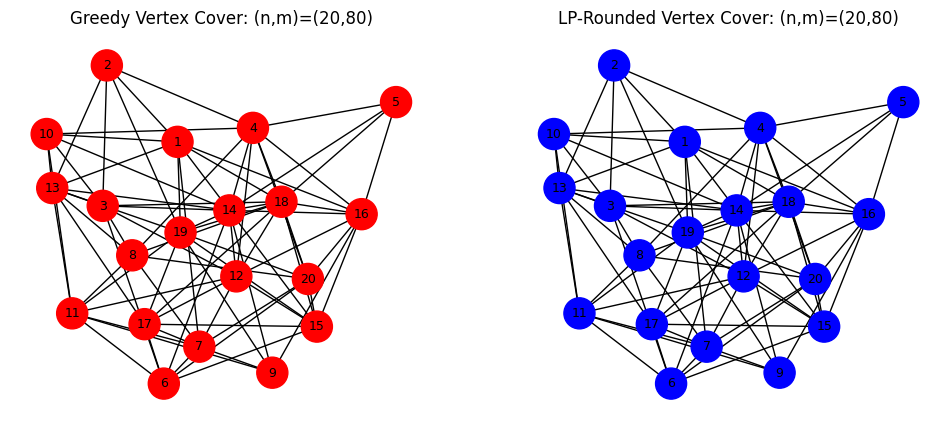

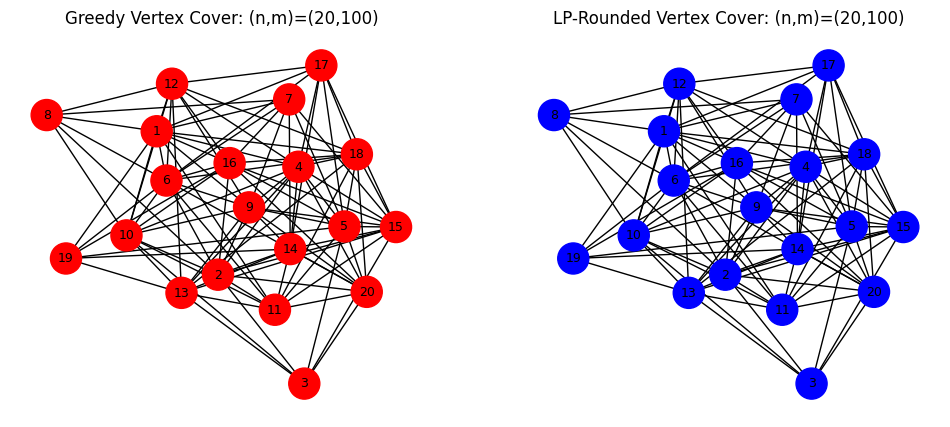

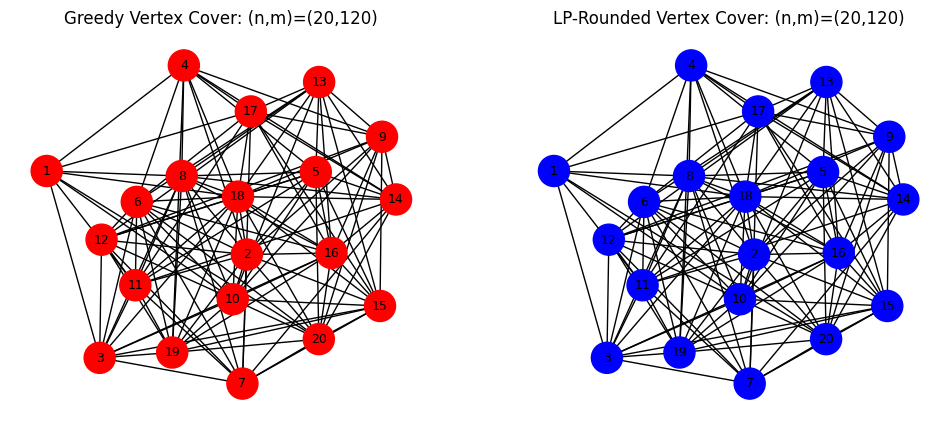

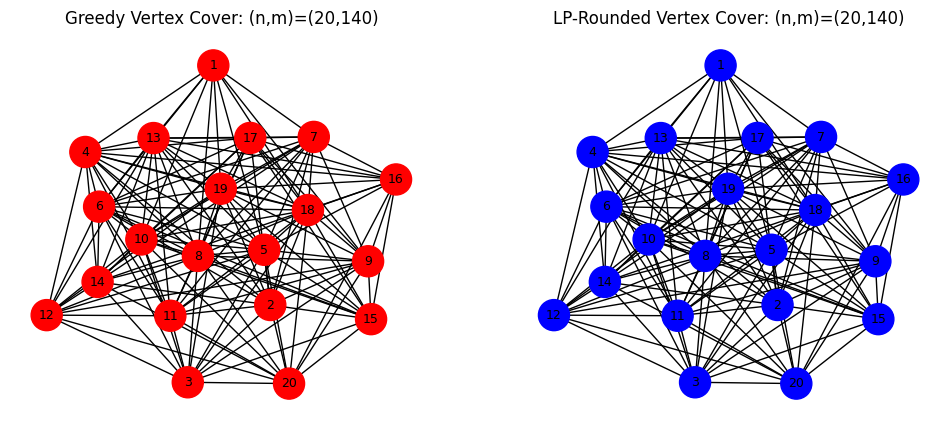

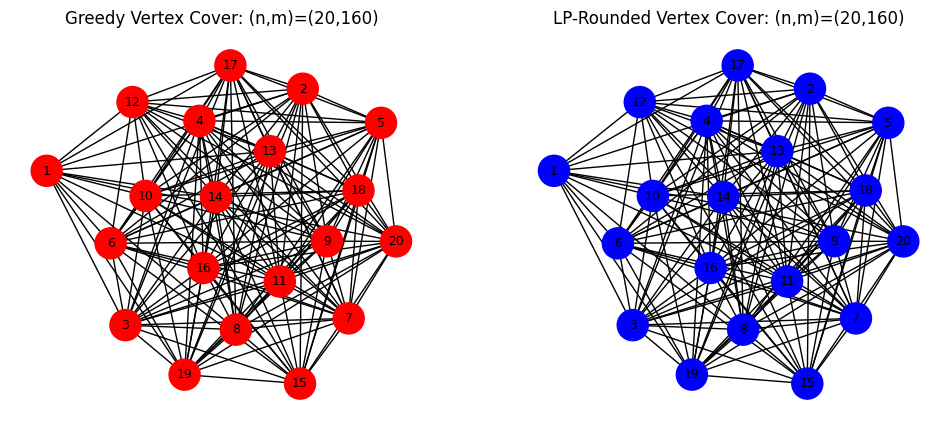

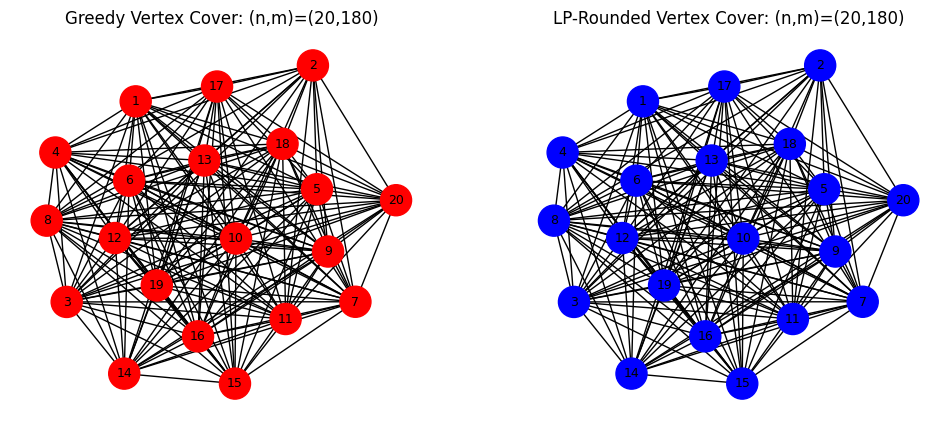

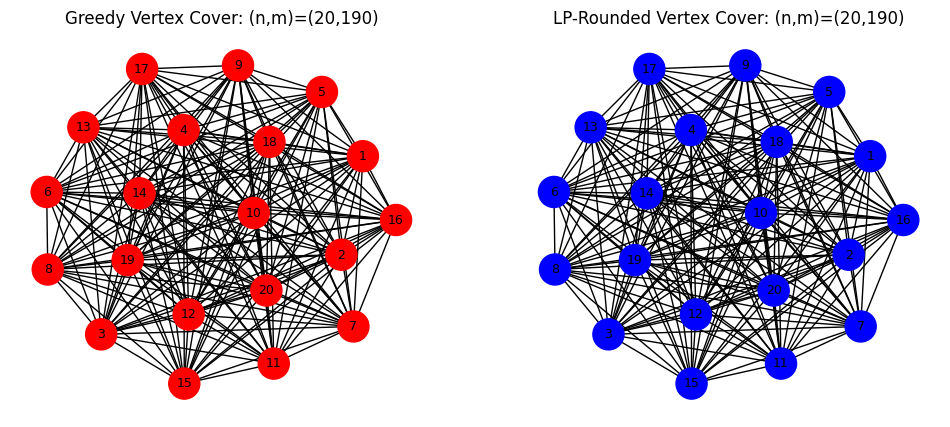

In [10]:
results = []

for n,edge_values in [(10,range(10,46,5)),(20,list(range(20,181,20))+[190])]:
    for m in edge_values:
        graph = nx.Graph()
        graph.add_nodes_from(range(1,n+1))

        while graph.number_of_edges() < m:
            start = random.randint(1,n)
            end = random.randint(1,n)
            if start != end:
                graph.add_edge(start,end)

        matching,greedy_cover = greedy_vertex_cover(graph)
        lp_opt,lp_rounded_cover = lp_vertex_cover(graph)

        pos = nx.spring_layout(graph,seed=42)

        plt.figure(figsize=(12,5))

        plt.subplot(1,2,1)
        nx.draw(graph,pos,with_labels=True,node_color=["red" if v in greedy_cover else "lightgray" for v in graph.nodes()],node_size=500,font_size=9)
        plt.title(f"Greedy Vertex Cover: (n,m)=({n},{m})")

        plt.subplot(1,2,2)
        nx.draw(graph,pos,with_labels=True,node_color=["blue" if v in lp_rounded_cover else "lightgray" for v in graph.nodes()],node_size=500,font_size=9)
        plt.title(f"LP-Rounded Vertex Cover: (n,m)=({n},{m})")

        plt.show()

        greedy_size = len(greedy_cover)
        lp_rounded_size = len(lp_rounded_cover)
        results.append([f"({n},{m})",lp_opt,lp_rounded_size,greedy_size,greedy_size/lp_opt,lp_rounded_size/lp_opt])

In [11]:
results_table = pd.DataFrame(results,columns=["(n,m)","LPopt","LPrdd","Greedy Size","Greedy/LPopt","LPrdd/LPopt"])
display(results_table)

,"(n,m)",LPopt,LPrdd,Greedy Size,Greedy/LPopt,LPrdd/LPopt
0,"(10,10)",4.0,6,8,2.000000,1.5
1,"(10,15)",4.0,4,8,2.000000,1.0
2,"(10,20)",4.5,9,6,1.333333,2.0
3,"(10,25)",5.0,10,10,2.000000,2.0
4,"(10,30)",5.0,10,10,2.000000,2.0
5,"(10,35)",5.0,10,10,2.000000,2.0
6,"(10,40)",5.0,10,10,2.000000,2.0
7,"(10,45)",5.0,10,10,2.000000,2.0
8,"(20,20)",7.0,7,12,1.714286,1.0
9,"(20,40)",10.0,18,16,1.600000,1.8


In [12]:
results_table.to_csv("P4_LP_Rounding_Results.csv",index=False)